<h1>TP2 - Gradient Descent<h1>
<h2>Thierno Daouda LY<h2>
<h3>DIC1 2024<h3>

<h2>Principe de la decente de gradient</h2>
L'equation normale permet de calculer directement la solution optimal d'une regression lineaire
Pour des donnees de grande taille le calcul de la solution optimale via l'equation normale est souvent couteux en ressource. Cela est lié en grande partie a la complexité du calcul de l'inverse d'une matrice de grande taille.
Une solution rapide a ce probleme est l'utilisation de la descente de gradient.
Le principe est de tracer la surface de la fonction de cout puis prendre un point aleatoire et suivre la pente descendante jusqu'a atteindre le minimum local. Dans certains exemples le cout peut avoir plusieurs minima locaux. On peut choisir dans ces cas plusieurs points aleatoires et prendre le plus petit des minima locaux trouvés comme solution.
<h2>Visualisation de la fonction de cout</h2>
<ol>
<li>
La fonction de cout est definie par :
$$
J(\theta) = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 \tag{1}
$$

ou
<ul>
-$J(\theta)$ est la fonction de coût,<br/>
-$m$ est le nombre d'exemples de données,<br/>
-$h_\theta(x^{(i)})$ est la fonction de prédiction du modèle pour l'exemple $i$<br/>
-$y^{(i)}$ la valeur reelle de l'exemple $i$<br/>

La fonction $h$ est definie par :
$$
h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_n x_n \tag{2}
$$

Créeons une fonction <b>compute_cost</b> permettant de calculer la fonction de cout. La fonction doit prendre en parametre x,y, theta (voir signature de la fonction en exemple)

</li>
</ol>




In [ ]:
import numpy as np
def compute_cost(X, y, theta):
    """
    Calcul du coût pour un modèle de régression linéaire à une seule variable.

    Arguments :
    X : numpy array, la matrice des caractéristiques (m lignes, 2 colonnes)
    y : numpy array, le vecteur des valeurs cibles (m lignes)
    theta : numpy array, le vecteur des paramètres du modèle (2 lignes)

    Retour :
    cost : float, le coût calculé à partir du Mean Squared Error
    """
    m = len(y)  # nombre d'exemples

    # Calcul de la prédiction h_theta(x) pour toutes les observations
    h_theta = np.dot(X, theta)

    # Calcul de la somme des erreurs au carré
    squared_errors = np.square(h_theta - y)

    # Calcul du coût (Mean Squared Error)
    cost = (1 / (2 * m)) * np.sum(squared_errors)

    return cost

<ol start="2">
<li>
  Charger les données du fichier data.txt la premiere colonne represente x et la deuxieme y
</li>
<li>Afficher la surface de la fonction de cout en fonction de theta0 et theta1. Vous pouvez utiliser la fonction plot_surface pour le faire

```
from matplotlib import cm

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(theta0_values, theta1_values, cost_values,cmap=cm.coolwarm)
plt.show()
```
theta0_values et theta0_values sont obtenues en utilisant la fonction np.meshgrid
</li>

<li>
  La courbe de la fonction de cout est difficilement interpretable (difficile de trouver visuellement le minimum local ). Cela est du essentiellement au fait que les x et y n'ont pas les meme ordres de valeurs. Pour resoudre se probleme on peut standardiser ou normaliser les données suivant x et y pour avoir des valeurs de meme ordre. La formule permettant de standardiser X est <br/>

$$
X_{\text{standardisé}} = \frac{X - \mu}{\sigma} \tag{3}
$$
avec $\mu$ la valeur moyenne de $X$ et $\sigma$ l'ecart type<br>
Creer une fonction permettant de standardiser un tableau numpy, la fonction doit retourner un tableau normalisé, la moyenne et l'ecart type
</li>

</ol>

In [ ]:

def standardisation(X):

    #return Xn,mean,std
    return 0,0,0

<ol start="5">
<li>
  Exprimer la fonction inverse permettant de retrouver la valeur reelle a partir de la valeur standard en fonction de la moyenne et de l'ecart type
</li>
<li>
  Implementer la fonction inverse destandardisation
</li>
</ol>

In [ ]:
def destandardisation(Xn,mean,std):

    #return X
    return 0

<ol start="7">
<li>
  Standardiser x et y et reafficher la surface de la fonction de cout en fonction de theta, les theta prendront des valeurs entre -4 et 4
  <br/>
  On aura le resultat suivant
</li>


  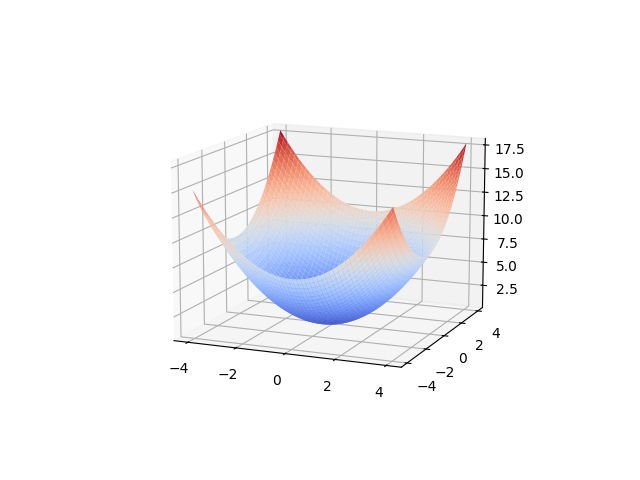

<img src=""/>

<ol start="8">
<li>
  afficher les contours sur une autre figure
  vous pouvez vous inspirer du code suivant

```
plt.figure(figsize=(10, 6))
plt.contour(t0_values, t1_values, cost_values.T, levels=np.logspace(-1, 1, 20), cmap=cm.coolwarm)

plt.xlabel('Theta0')
plt.ylabel('Theta1')
plt.title('Coût en fonction de Theta0 et Theta1')
plt.colorbar(label='Coût')
plt.show()
```

  vous devez avoir un resultat semblable a la figure suivante. On peut sur cette figure estimer les valeurs de theta0 theta1 correspondantes au minimum local

  

</ol>

<img src="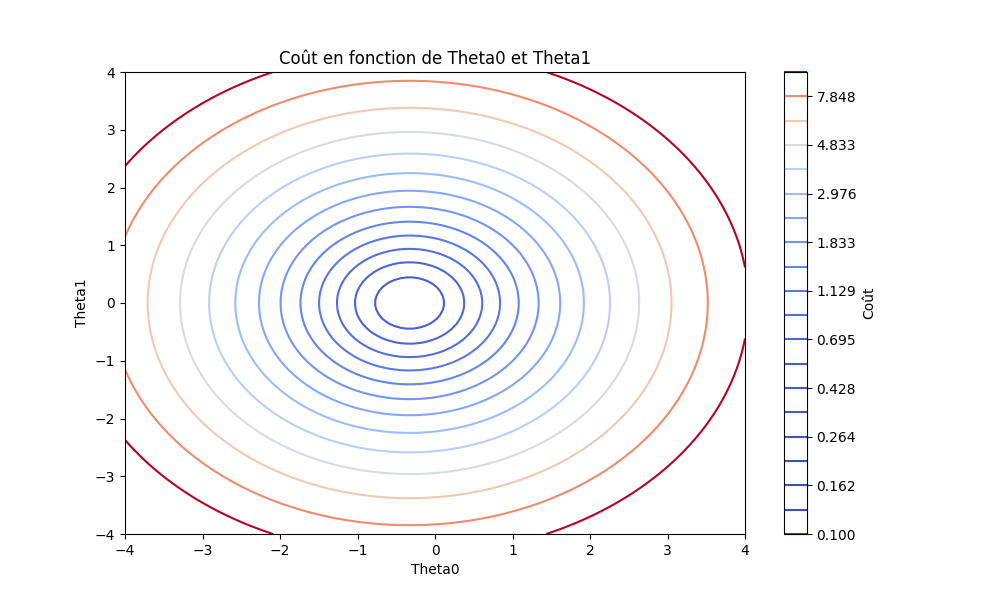
"/>

<h2>Gradient descent</h2>
Le gradien descent consiste a soustraire de θ de facon iterative le gradien de $J$ (par rapport a θ) multiplier par un parametre α.
on a ainsi

$$
θ:=θ−α\nabla{J(θ)} \tag{4}
$$

α est appelé taux d'apprentissage (learning rate), un paramètre fixe contrôlant la taille des pas de mise à jour

on peut reecrire l'equation $(4)$
$$
\left\{
    \begin{array}{ll}
        \theta_1 := \theta_1 - α \frac{\partial J(θ)}{\partial θ_1} \\
        \theta_2 := \theta_2 - α \frac{\partial J(θ)}{\partial θ_2}
    \end{array}
\right. \dot(5)
$$

<ol start="9">
<li>
Montrez que l'equation 5 peut s'ecrire sous la forme de :
$$
\left\{
    \begin{array}{ll}
        \theta_1 := \theta_1 - \frac{2α}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) \\
        \theta_2 := \theta_2 - \frac{2α}{m} \sum_{i=1}^{m} x^{(i)}(h_\theta(x^{(i)}) - y^{(i)})
    \end{array}
\right. \dot(6)
$$
</li>
<li>
La forme vectorielle du gradient est donnee par l'equation ci dessous
$$\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)\dot(7)$$
Creer une fonction python permettant de calculer le gradient d'une fonction
</li>

<li>
  creer une fonction python implemantant l'algorithme du gradient descent
  la fonction prend en entrees x,y $θ_{initial}$, α et maxIter avec max_iter le nombre d'iteration la fonction retourne theta, jHistory, thetaHistory
</li>
<li>
  tester la fonction en initialisant θ=(0,0) et maxIter=1000 et α=0,1
  puis tracer la courbe J en fonction du nombre d'iteration dans une nouvelle figure
</li>
<li>
  pour $\alpha=0.1$, $θ=(3,3)$ et le $maxIter=5$
  tracer la surface $J(θ)$ et placer les points correspondant aux valeurs de J(θ) lorsque θ prend les faleurs thetaHistory
</li>
<li>
  Modifier la fonction implementant le gradient descent pour qu'elle exporte dans un fichier gif l'evolution de J en fonction des iterations pour cela vous pouvez placer successivement les points $(θ_0,θ_1, J(θ_0,θ_1)$ sur la figure 3d), pour chaque point placé exporter l'image du graph, puis convertire les images en fichier gif
</li>
<li>
en jouant sur les parametres α et $maxIter$ expliquer

  <ul>
  <li>l'impact d'un α trop petit et d'un α trop grand.</li>

  <li>l'impact d'un nombre d'iterations trop petit ou d'un nombre d'iteration trop grand</li>
  </ul>
</ol>

<h2>Variantes du grandian descente</h2>
Rappeler les avantages et inconvénient, puis implémenter et tester les méthodes de descente de gradient suivantes
<ol start="16">
<li>
  Descente de gradient stochastique
</li>
<li>
  Descente de gradient par mini-lots
</li>
<li>
Faire une analyse comparative entre les differentes variantes du gradian descente
</li>
<li>
  pour θ=(-3,2) et maxIter=1000, tracer la valeur de la fonction de cout en fonction du nombre d'iteration sur une seule figure en utilisant successievemnt les differentes variantes du gradient descente
</li>
<li>
Conclure
</li>
</ol>

<h2>Régression polynomial</h2>
La regression lineaire permet de chercher une $θ_0$ et $θ_1$ tel que
l'erreur quadratique $\sum (θ_0+θ_1x_i-y_i)^2$ soit minimal. Le resultat sera une droite qui minimise sa distance avec les points representants les données d'entrainement

Pour la regression polynomiale il s'agira de chercher un polynome telque de degre $n$ telque $\sum (θ_0+θ_1x_1+\dots+θ_nx_n-y_i)^2$ soit minimal

on peut definir ainsi la fonction de cout

$$
J(\theta) = \frac{1}{m} \sum_{j=1}^{m}\biggl( y^{(j)} -\sum_{i=1}^{n} \theta_ix_i^{(j)}\biggr)^2 \tag{8}
$$